# Análisis exploratorio

### 1) importaciones, lecturas y merges

In [13]:
import os
import pathlib
import math

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import seaborn as sns
import pandas as pd
import json

In [2]:
QA_dir = '../QA'
entity_dir = '../Datasets'
QA_df = pd.read_csv(os.path.join(QA_dir, "QA_final.csv"))

# Cargamos los tipos de entidad
folder_entity_types = os.path.join(entity_dir, "entity_types_clean")
files_entity_types = os.listdir(folder_entity_types)
roots_entitity_type = [os.path.join(folder_entity_types, file) for file in files_entity_types if file.endswith('.csv')]
entity_types_dfs = {files_entity_types[i].split(".")[0]: pd.read_csv(roots_entitity_type[i]) for i in range(len(roots_entitity_type))}
big_entity_types_df = pd.concat(entity_types_dfs.values(), ignore_index=True)
big_entity_types_df = big_entity_types_df.drop_duplicates(subset=['entidad', 'tipo_entidad'])

# Cruzamos los tipos de entidades con las tripletas
merged_df = QA_df.merge(
    big_entity_types_df,
    left_on='entidad',
    right_on='entidad',
    how='left'
)

merged_df['obtenido_de'] = merged_df['obtenido_de'].apply(lambda x: eval(x)[0] if pd.notnull(x) else x)

# Separamos los dataframes por país y tipo de entidad
entidades_humanas = merged_df[merged_df['tipo_entidad'] == "ser humano".strip()]
entidades_no_humanas = merged_df[merged_df['tipo_entidad'] == "ser humano".strip()]

entidades_humanas_por_pais = {pais: entidades_humanas[entidades_humanas['obtenido_de'] == pais] for pais in entidades_humanas['obtenido_de'].unique()}
entidades_no_humanas_por_pais = {pais: entidades_no_humanas[entidades_no_humanas['obtenido_de'] == pais] for pais in entidades_humanas['obtenido_de'].unique()}

conteo_humanos_por_pais = entidades_humanas.groupby('obtenido_de')['entidad'].nunique().reset_index()
conteo_no_humanos_por_pais = entidades_no_humanas.groupby('obtenido_de')['entidad'].nunique().reset_index()

In [3]:
humans = merged_df[merged_df['tipo_entidad'] == "ser humano".strip()]
non_humans = merged_df[merged_df['tipo_entidad'] != "ser humano".strip()]
prop = len(humans) / len(merged_df)
print(f"Proporción de tripletas con entidades personas: {prop:.2%} ({len(humans)} de {len(merged_df)})")
print(f'Es decir, hay {len(humans)} tripletas para entidades personas y {len(non_humans)} para entidades no personas.')

Proporción de tripletas con entidades personas: 87.62% (42732 de 48769)
Es decir, hay 42732 tripletas para entidades personas y 6037 para entidades no personas.


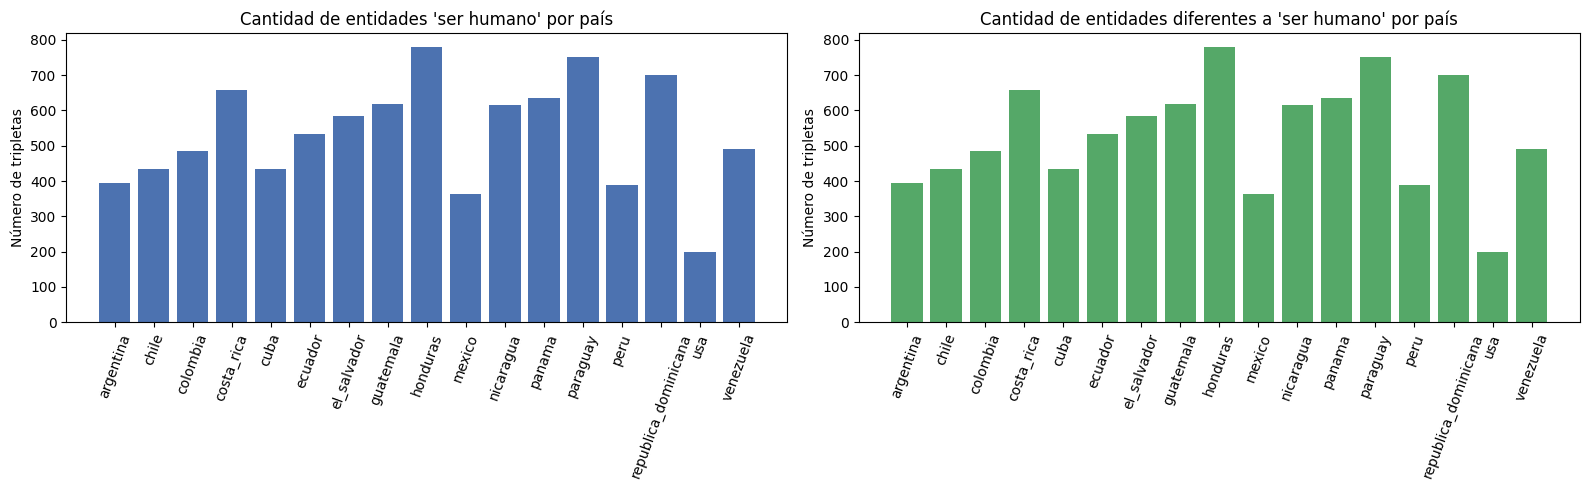

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(conteo_humanos_por_pais['obtenido_de'],
            conteo_humanos_por_pais['entidad'],
            color="#4C72B0")
axes[0].set_title("Cantidad de entidades 'ser humano' por país")
axes[0].set_ylabel("Número de tripletas")
axes[0].tick_params(axis='x', rotation=70)

axes[1].bar(conteo_no_humanos_por_pais['obtenido_de'],
            conteo_no_humanos_por_pais['entidad'],
            color="#55A868")
axes[1].set_title("Cantidad de entidades diferentes a 'ser humano' por país")
axes[1].set_ylabel("Número de tripletas")
axes[1].tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.show()

### 2) Relaciones más frecuentes para entidades (personas y objetos)

In [5]:
def plot_relations(data, top_n=15, title_suffix='ser humano'):
    plt.figure(figsize=(16, 9))
    sns.barplot(
        data=data.head(top_n),
        y='relacion',
        x='count',
        hue='relacion',
        palette='viridis',
        legend=False
    )
    plt.xlabel('Frecuencia')
    plt.ylabel('Relación')
    plt.title(f'Top {top_n} relaciones más frecuentes para {title_suffix}')
    plt.tight_layout()
    plt.show()

['ciudadania', 'ocupacion', 'fecha de nacimiento', 'lugar de nacimiento', 'fecha de defuncion', 'educado en', 'cargo', 'premio recibido', 'empleador', 'miembro de']


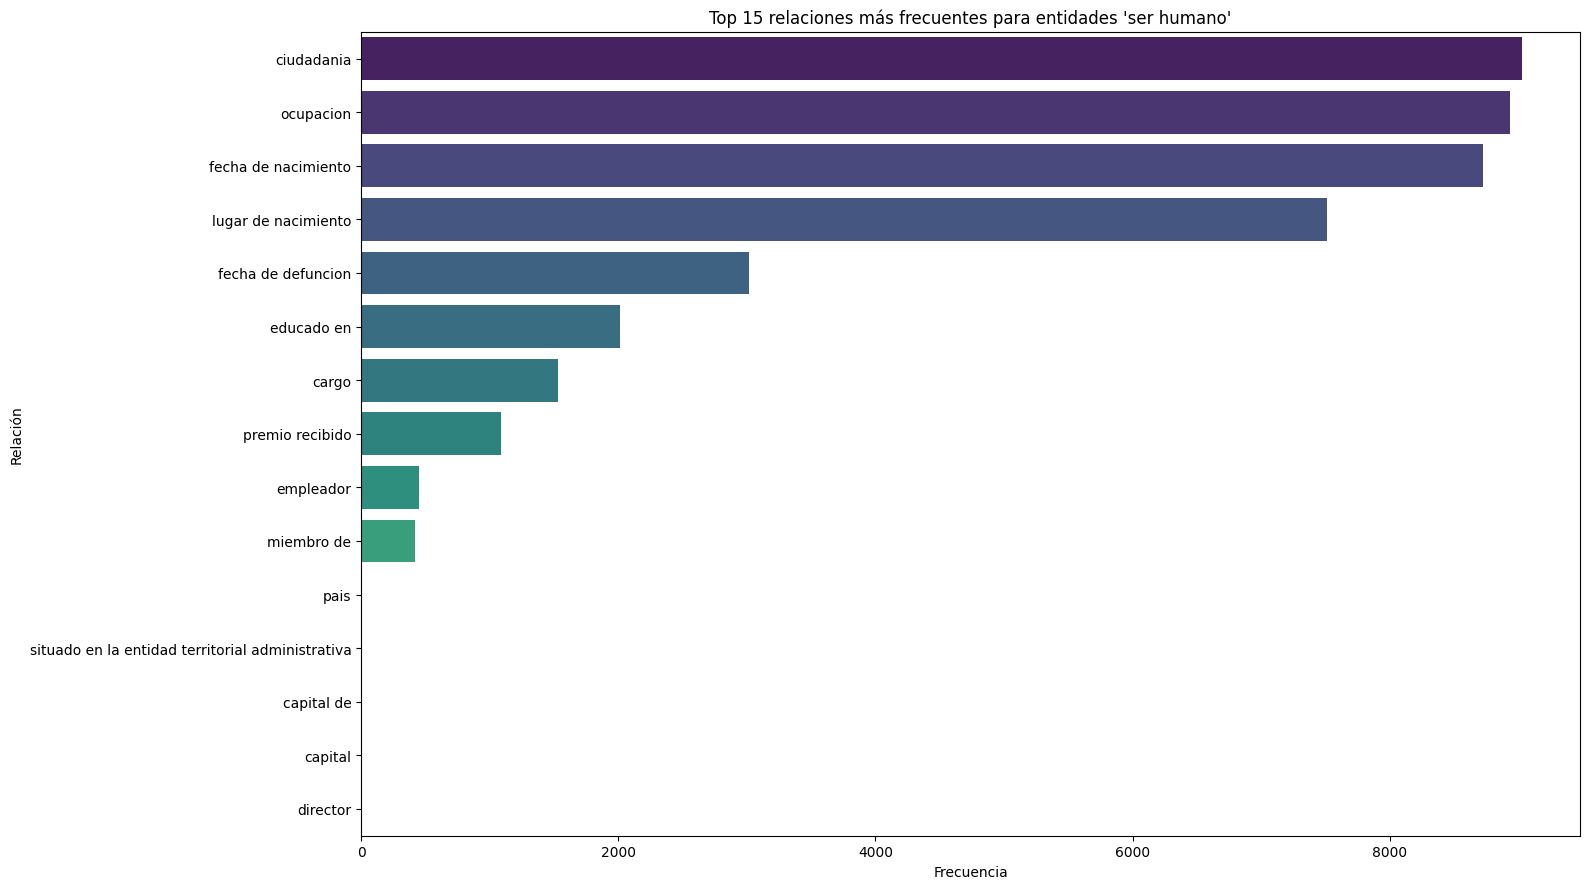

In [6]:
human_relation_counts = merged_df[merged_df['tipo_entidad'] == "ser humano"]
human_relation_counts = human_relation_counts['relacion'].value_counts().reset_index()
print(human_relation_counts[human_relation_counts['count'] >= 100]['relacion'].to_list())
plot_relations(human_relation_counts, title_suffix="entidades 'ser humano'")

['pais', 'situado en la entidad territorial administrativa', 'comparte fronteras con', 'jefe de gobierno', 'fundador', 'continente', 'ubicacion de la sede', 'capital', 'genero', 'miembro de', 'nombrado en referencia a', 'idioma de la obra o del nombre', 'idioma oficial', 'pais de origen', 'santo patron', 'autor', 'situado cerca del cuerpo de agua', 'conferido por', 'capital de', 'ciudadania', 'ubicacion', 'fecha de nacimiento', 'ocupacion']
60


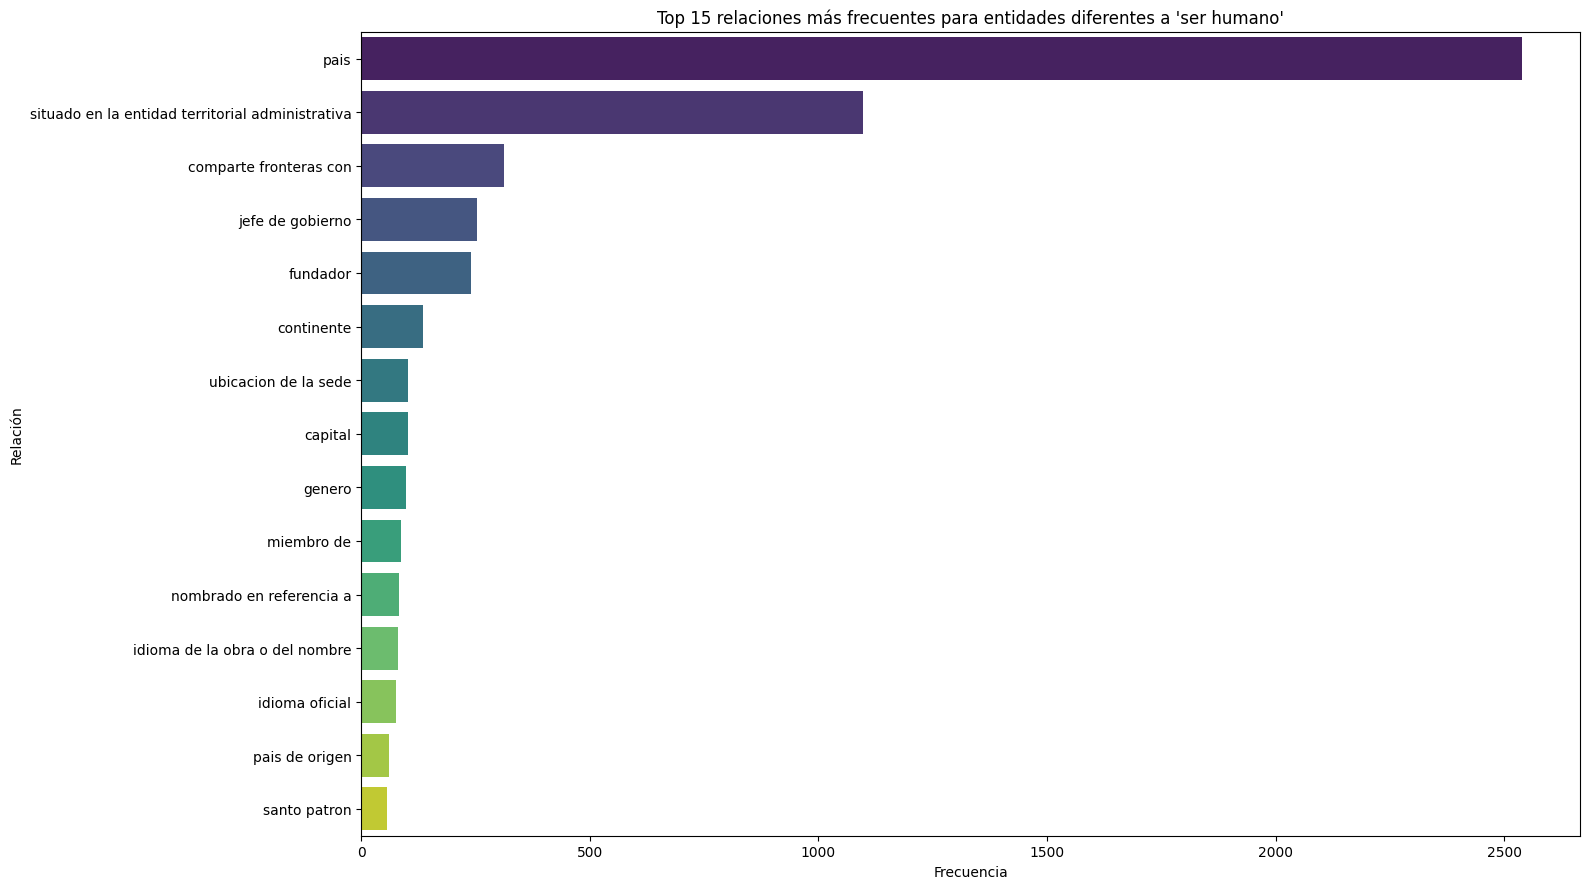

In [7]:
non_human_relation_counts = merged_df[merged_df['tipo_entidad'] != "ser humano"]
non_human_relation_counts = non_human_relation_counts['relacion'].value_counts().reset_index()
print(non_human_relation_counts[non_human_relation_counts['count'] >= 30]['relacion'].to_list())
print(len(non_human_relation_counts[non_human_relation_counts['count'] >= 0]['relacion'].to_list()))
plot_relations(non_human_relation_counts, title_suffix="entidades diferentes a 'ser humano'")

### 2) Relaciones promedio por entidad

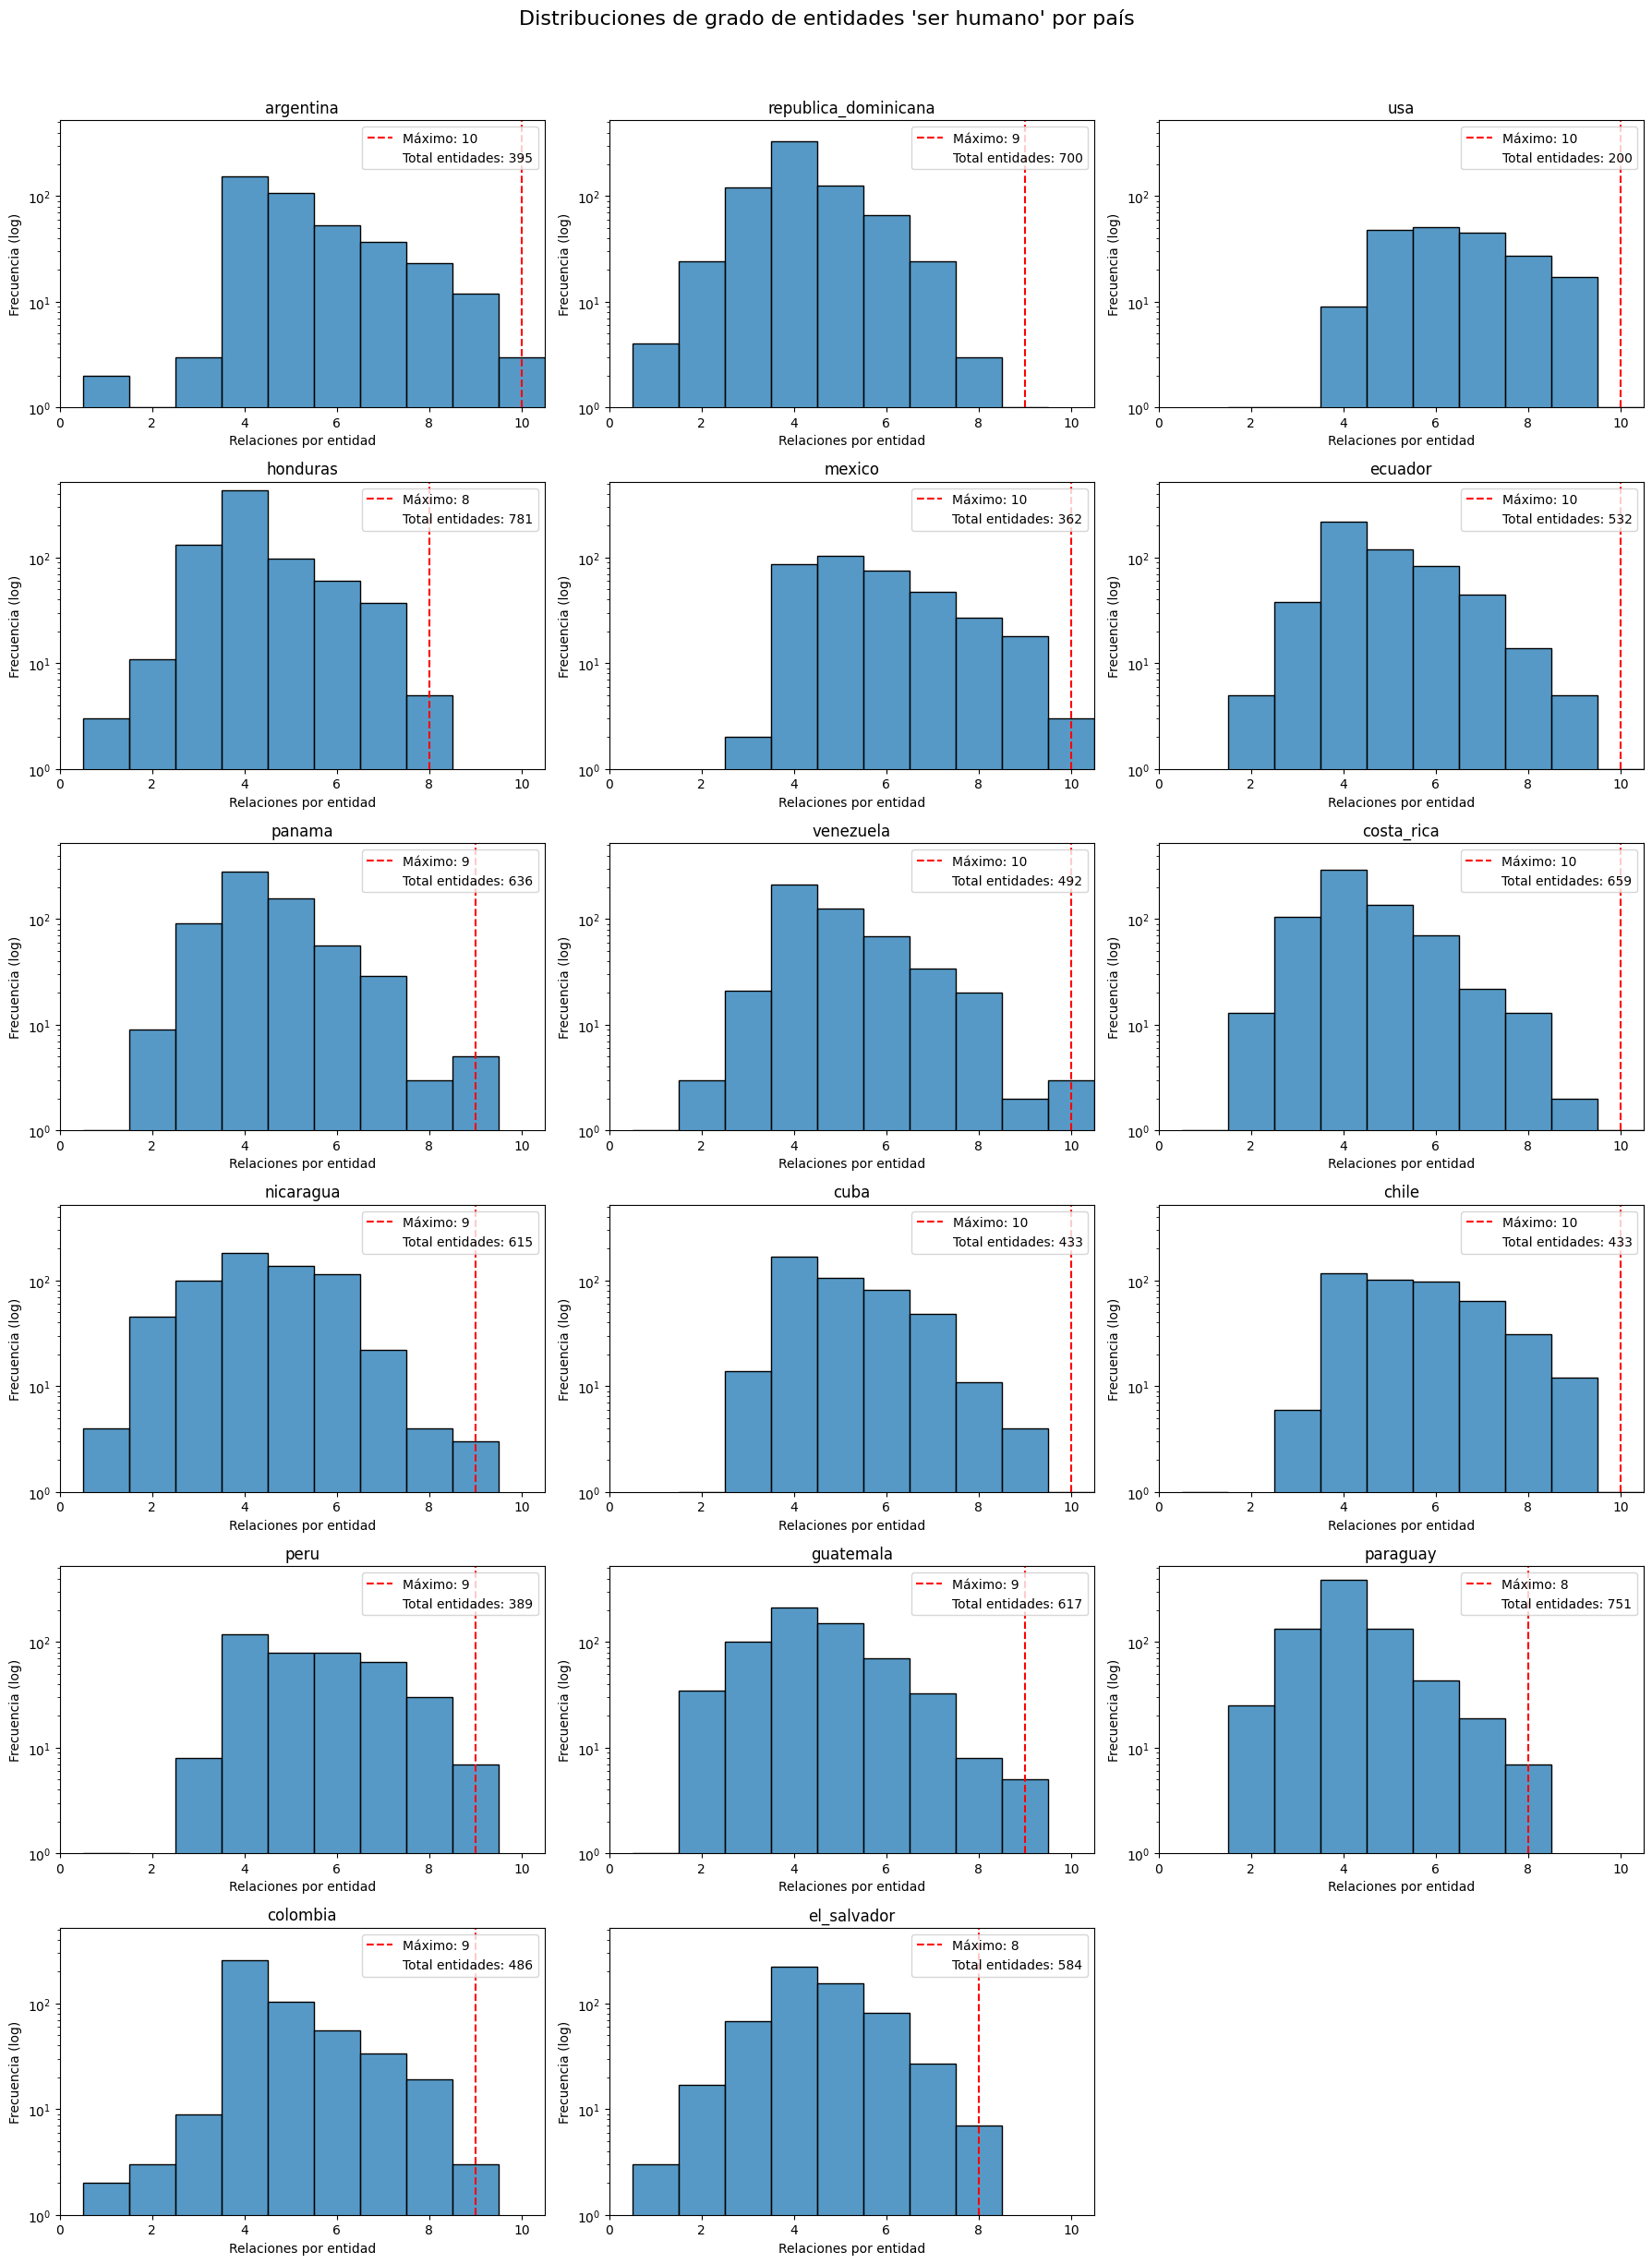

In [8]:
def plot_entity_degree_distributions(df_dict, suptitle):
    total_files = len(df_dict)
    max_x = 0
    max_y = 0
    data_dict = {}

    # Precalcula grados por archivo y máximos globales
    for country, df in df_dict.items():
        entity_degrees = df['entidad'].value_counts()
        data_dict[country] = entity_degrees
        max_x = max(max_x, entity_degrees.max())
        max_y = max(max_y, entity_degrees.value_counts().max())

    cols = 3 if total_files >= 3 else total_files
    rows = math.ceil(total_files / cols) if total_files > 0 else 1
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if total_files > 1 else [axes]

    for i, country in enumerate(df_dict.keys()):
        series = len(data_dict[country])
        max_val = max(data_dict[country])
        sns.histplot(data_dict[country], bins=range(0, max_x + 2), kde=False, ax=axes[i], discrete=True,)
        axes[i].axvline(x=max_val, color='r', linestyle='--', linewidth=1.5, label='Media')
        axes[i].legend([f'Total entidades: {series}'], loc='upper right')
        axes[i].set_xmargin(0)
        axes[i].set_xlim(0, max_x * 1.05)
        axes[i].set_yscale('log')
        axes[i].set_ylim(1, max_y * 1.2)
        axes[i].set_xlabel('Relaciones por entidad')
        axes[i].set_ylabel('Frecuencia (log)')
        axes[i].set_title(country.replace('.csv', ''))
        total_handle = Patch(facecolor='none', edgecolor='none',
                            label=f'Total entidades: {series}')

        axes[i].legend(handles=[Line2D([], [], color='r', linestyle='--', label=f'Máximo: {max_val}'), total_handle], loc='upper right')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(suptitle, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
plot_entity_degree_distributions(entidades_humanas_por_pais, "Distribuciones de grado de entidades 'ser humano' por país")

In [9]:
# Muchas relaciones poco relevantes
df_cuba = entidades_humanas_por_pais['cuba']
df_cuba[df_cuba['entidad'] == 'Fidel Castro'].tail(10)

,entidad,relacion,objetos,pregunta,respuestas,obtenido_de,respuestas_aliases,tipo_entidad
3855,Fidel Castro,ciudadania,['cuba'],Contesta la siguiente pregunta: ¿Cuál es la ci...,['cuba'],cuba,"[['cuba', 'republica de cuba', 'republica de c...",ser humano
12798,Fidel Castro,fecha de nacimiento,['1926-08-13'],Contesta la siguiente pregunta: ¿Cuál es la fe...,['1926-08-13'],cuba,[[]],ser humano
21640,Fidel Castro,ocupacion,"['abogado', 'politico', 'dictador', 'guerrille...",Contesta la siguiente pregunta: ¿Cuál es la oc...,"['abogado', 'politico', 'dictador', 'guerrille...",cuba,"[['abogado', 'licenciado'], ['politico'], ['di...",ser humano
28589,Fidel Castro,fecha de defuncion,['2016-11-25'],Contesta la siguiente pregunta: ¿Cuándo fallec...,['2016-11-25'],cuba,[[]],ser humano
30777,Fidel Castro,miembro de,"['movimiento 26 de julio', 'partido ortodoxo']",Contesta la siguiente pregunta: ¿De qué organi...,"['movimiento 26 de julio', 'partido ortodoxo']",cuba,"[['movimiento 26 de julio', 'm-26-7', 'movimie...",ser humano
31827,Fidel Castro,educado en,"['universidad de la habana', 'colegio de belen']",Contesta la siguiente pregunta: ¿Dónde estudió...,"['universidad de la habana', 'colegio de belen']",cuba,"[['universidad de la habana'], ['colegio de be...",ser humano
35755,Fidel Castro,lugar de nacimiento,['biran'],Contesta la siguiente pregunta: ¿Dónde nació F...,['biran'],cuba,[['biran']],ser humano
46588,Fidel Castro,cargo,"['presidente de cuba', 'primer secretario del ...",Contesta la siguiente pregunta: ¿Qué cargo ocu...,"['presidente de cuba', 'primer secretario del ...",cuba,"[['presidente de la republica de cuba', 'presi...",ser humano
48043,Fidel Castro,premio recibido,['premio internacional gadafi de los derechos ...,Contesta la siguiente pregunta: ¿Qué premio re...,['premio internacional gadafi de los derechos ...,cuba,"[[], ['orden del merito', 'orden del merito'],...",ser humano


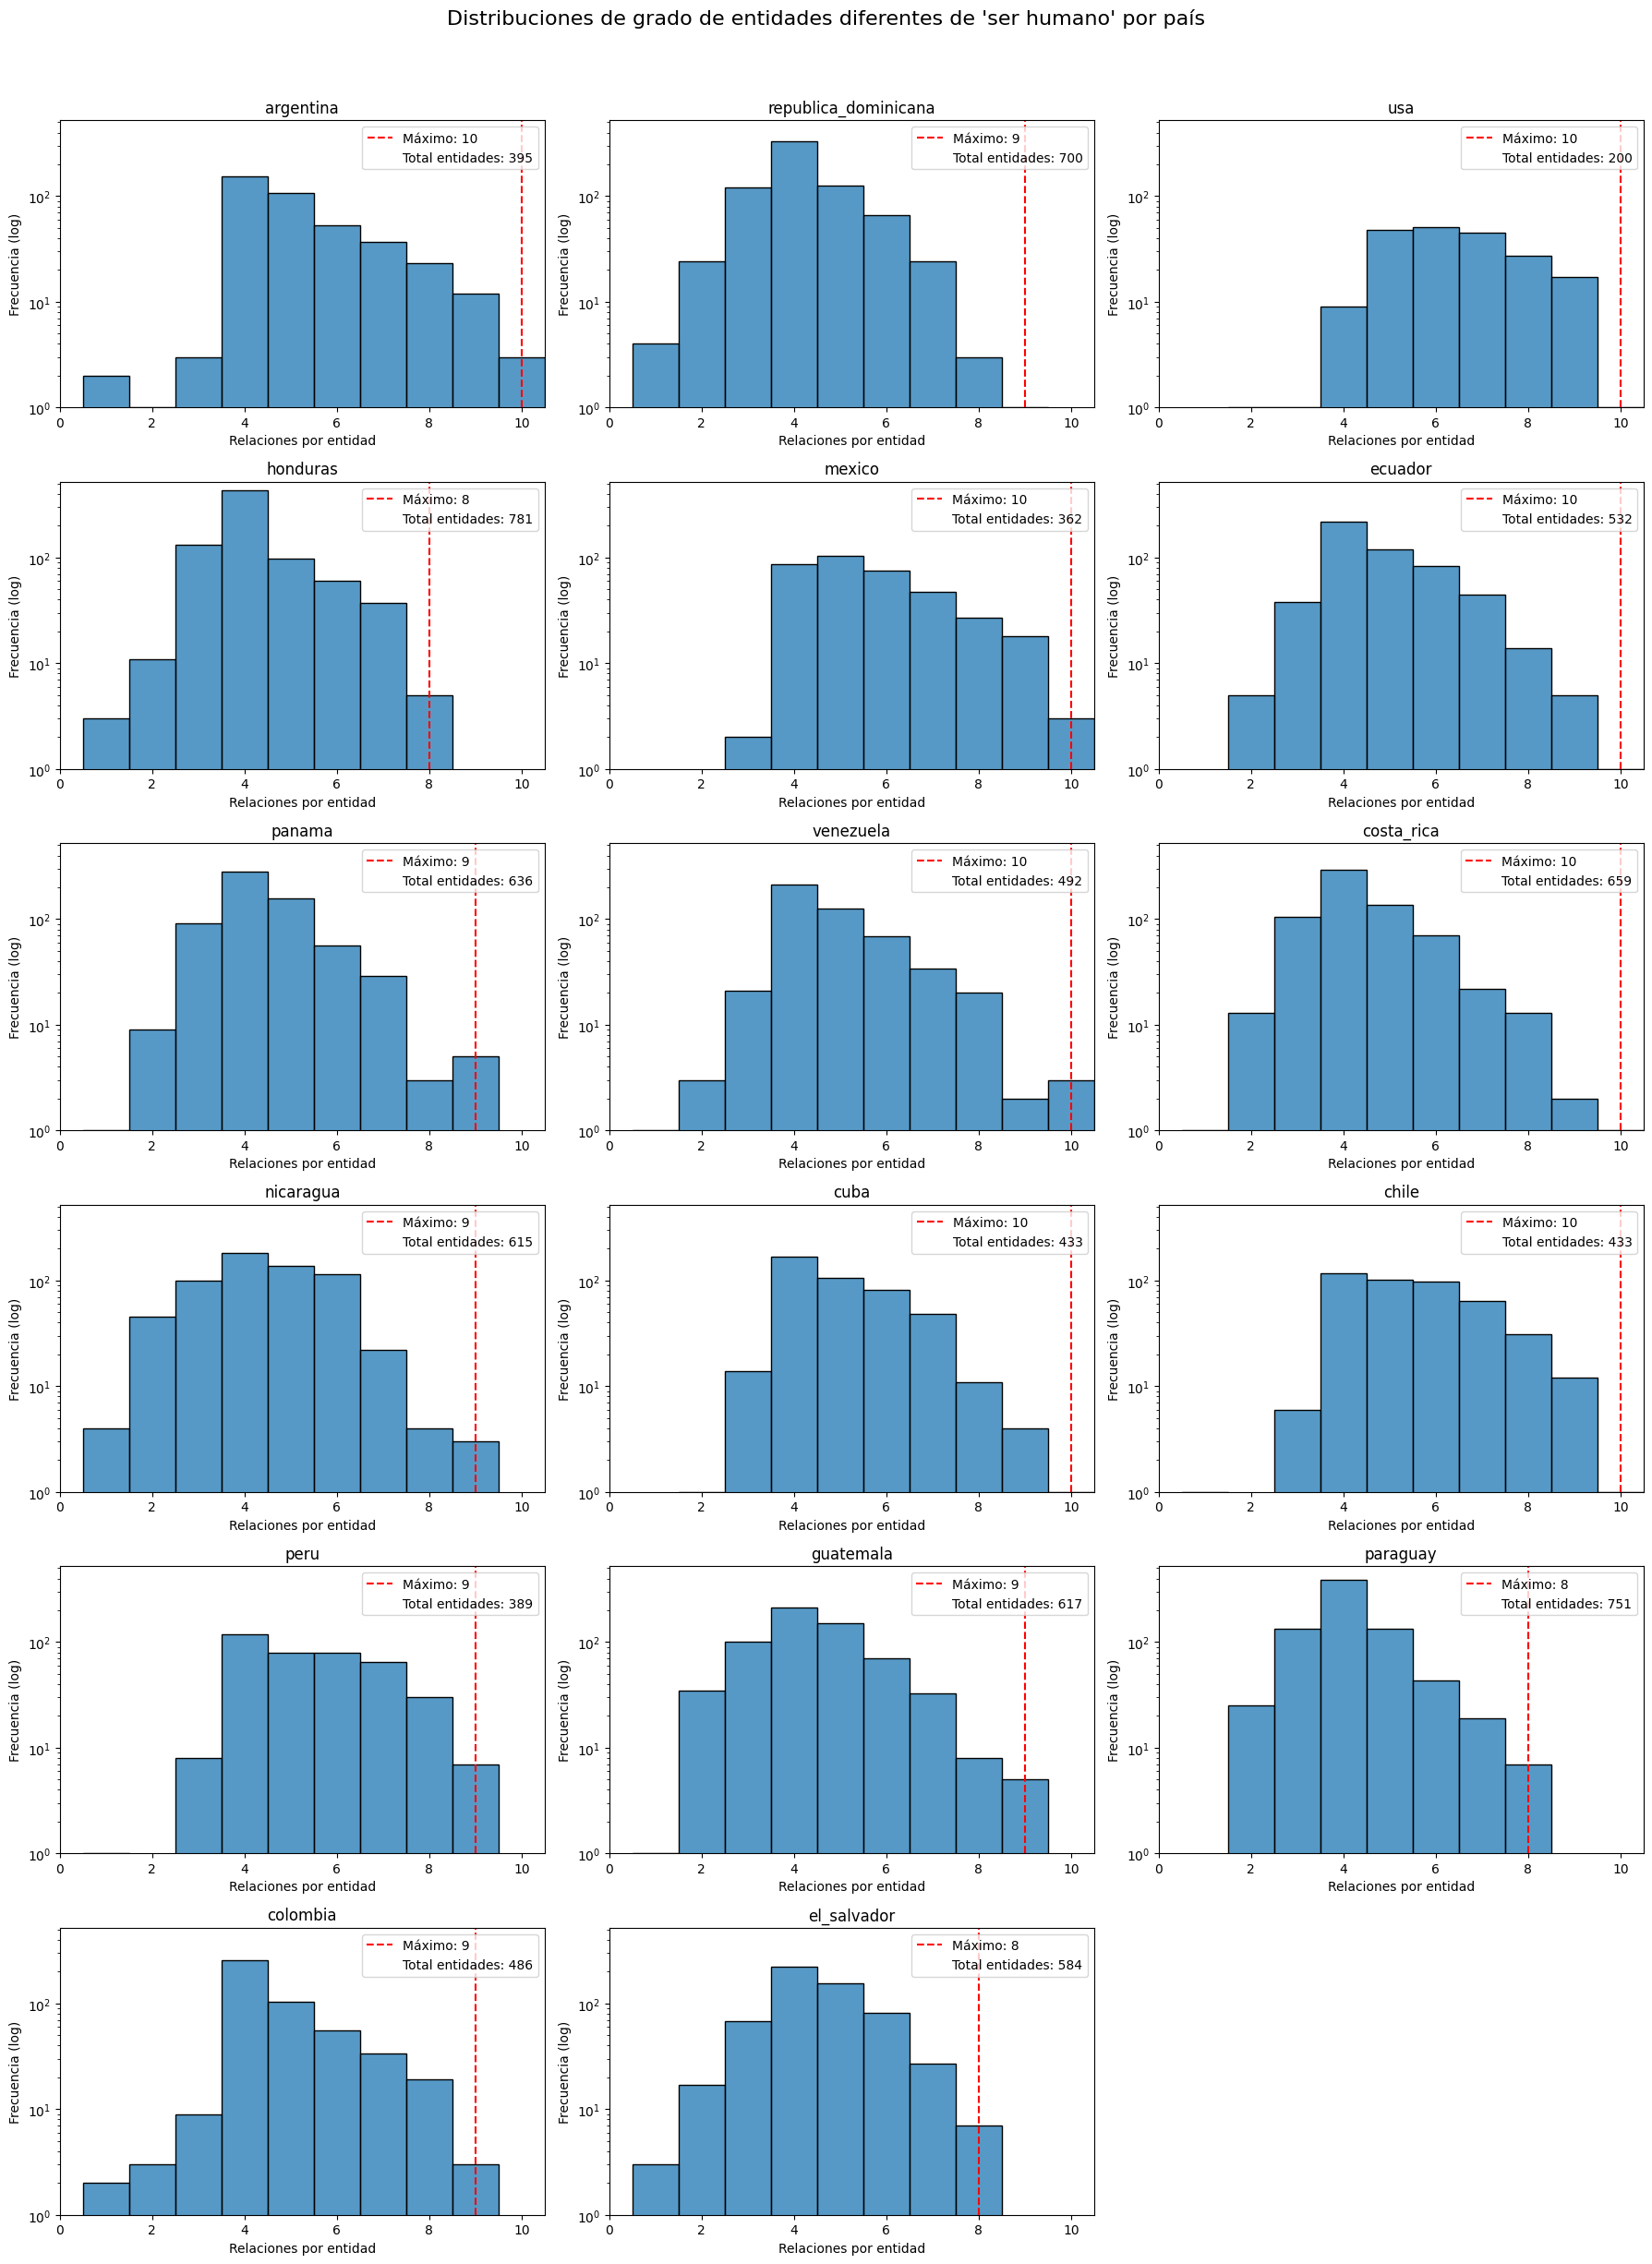

In [10]:
plot_entity_degree_distributions(entidades_no_humanas_por_pais, "Distribuciones de grado de entidades diferentes de 'ser humano' por país")

## Benchamark plots

In [ ]:
qwen_path = '../Results/Qwen/Qwen_results.json'
# data = json.load()
 